In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 4
### a)

In [20]:
# Problems were solved hardcoded on own, Claude helped generalize for variable instances


states = []
n_agents = 3
for a in range(n_agents+1):
    for b in range(n_agents+1-a):
        c = n_agents - a - b
        states.append((a, b, c))

print(f"States order: {states}")


n_states = len(states)
init = [0] * (n_states)
init[-1] = 1 # initial state is (0, 0, 3)


Q = np.zeros((n_states, n_states))

state_index = {state: i for i, state in enumerate(states)}
rate_0 = 1.4
rate_1 = 0.8
rate_2 = 0.3

for i, (a, b, c) in enumerate(states):
    if a > 0: # A -> B
        new_state = (a-1, b+1, c)
        if b == 0:
            rate = a * rate_0
        elif b == 1:
            rate = a * rate_1
        else:
            rate = a * rate_2

        Q[i, state_index[new_state]] = rate

    if b > 0: # B -> C
        new_state = (a, b-1, c+1)
        if c == 0:
            rate = b * rate_0
        elif c == 1:
            rate = b * rate_1
        else:
            rate = b * rate_2

        Q[i, state_index[new_state]] = rate

    if c > 0: # C -> A
        new_state = (a+1, b, c-1)
        if a == 0:
            rate = c * rate_0
        elif a == 1:
            rate = c * rate_1
        else:
            rate = c * rate_2

        Q[i, state_index[new_state]] = rate


for row in range(Q.shape[0]):
    Q[row, row] = -np.sum(Q[row])
print(Q)



P = np.zeros(Q.shape)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        if i != j:
            P[i, j] = Q[i, j] / -Q[i, i]
        else:
            P[i, j] = 0

def sample_path(Q, a, T):
    P = np.zeros(Q.shape)
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            if i != j:
                P[i, j] = Q[i, j] / -Q[i, i]
            else:
                P[i, j] = 0


    path = [init.index(1)]
    jump_rates = []
    holding_times = []

    while sum(holding_times) < T:
        jump_rates.append(float(-Q[path[-1], path[-1]]))
        holding_times.append(np.random.exponential(1 / jump_rates[-1]))
        path.append(np.random.choice(range(len(states)), p=P[path[-1]]))

    return path[:-1], jump_rates[:-1], holding_times[:-1] # discard the last jump and holding time since they exceed T

States order: [(0, 0, 3), (0, 1, 2), (0, 2, 1), (0, 3, 0), (1, 0, 2), (1, 1, 1), (1, 2, 0), (2, 0, 1), (2, 1, 0), (3, 0, 0)]
[[-4.2  0.   0.   0.   4.2  0.   0.   0.   0.   0. ]
 [ 0.3 -3.1  0.   0.   0.   2.8  0.   0.   0.   0. ]
 [ 0.   1.6 -3.   0.   0.   0.   1.4  0.   0.   0. ]
 [ 0.   0.   4.2 -4.2  0.   0.   0.   0.   0.   0. ]
 [ 0.   1.4  0.   0.  -3.   0.   0.   1.6  0.   0. ]
 [ 0.   0.   0.8  0.   0.8 -2.4  0.   0.   0.8  0. ]
 [ 0.   0.   0.   0.3  0.   2.8 -3.1  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   2.8  0.  -3.1  0.   0.3]
 [ 0.   0.   0.   0.   0.   0.   1.6  1.4 -3.   0. ]
 [ 0.   0.   0.   0.   0.   0.   0.   0.   4.2 -4.2]]


### b)
The total jump rate is calculated by the negative (positive value) of the diagonal entries of the Q matrix, depending on which state you're in. \
The holding time is generated by taking a random exponential sample using a parameter of the jump rate. \
The next transition is selected by constructing the P matrix and sampling from the probabilities of the corresponding row in it.

### c)

In [21]:
MC_runs = 1000
results = {t: [] for t in np.arange(0.05, 5.01, 0.05)}
for t in np.arange(0.05, 5.01, 0.05):
    for _ in range(MC_runs):
        path, jump_rates, holding_times = sample_path(Q, a, t)
        #print(f"Time: {t:.2f}, Path: {[states[i] for i in path]}, Jump Rates: {jump_rates}, Holding Times: {holding_times}")
        results[t].append(states[path[-1]][0]) # append the number of agents in state A at time t

### d)

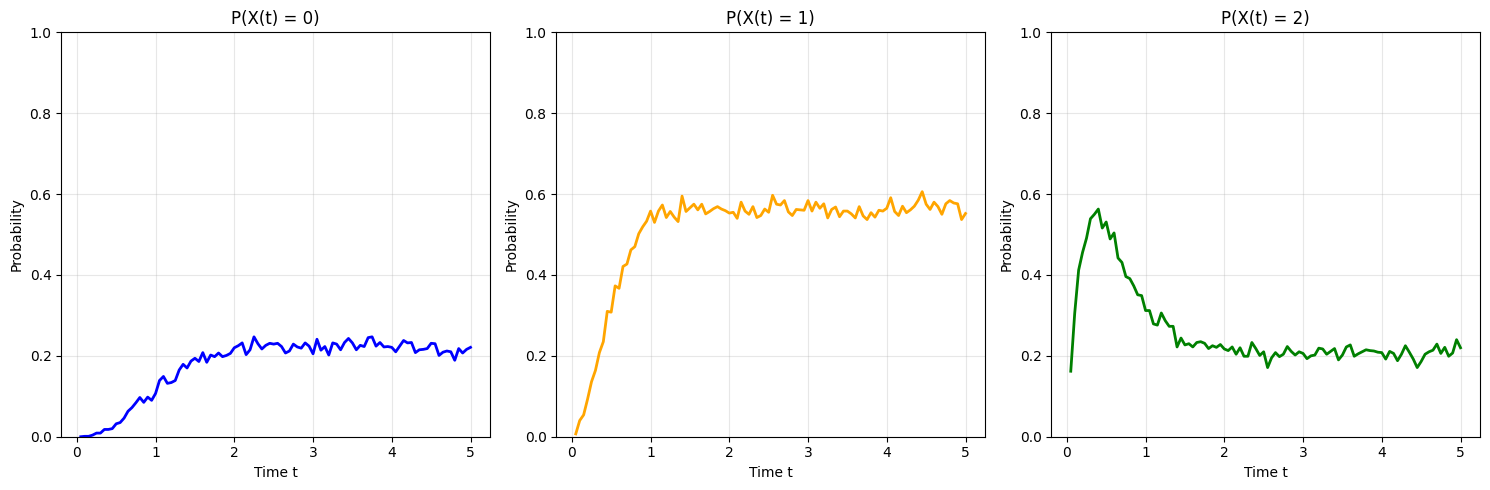

In [22]:
# Calculate probabilities for each state at each time
times = np.arange(0.05, 5.01, 0.05)
prob_state_0 = []
prob_state_1 = []
prob_state_2 = []

for t in times:
    prob_state_0.append(results[t].count(0) / MC_runs)
    prob_state_1.append(results[t].count(1) / MC_runs)
    prob_state_2.append(results[t].count(2) / MC_runs)

# OPTION 1: Line plots (cleaner, easier to read trends)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: State 0
axes[0].plot(times, prob_state_0, linewidth=2, color='blue')
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Probability')
axes[0].set_title('P(X(t) = 0)')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# Subplot 2: State 1
axes[1].plot(times, prob_state_1, linewidth=2, color='orange')
axes[1].set_xlabel('Time t')
axes[1].set_ylabel('Probability')
axes[1].set_title('P(X(t) = 1)')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Subplot 3: State 2
axes[2].plot(times, prob_state_2, linewidth=2, color='green')
axes[2].set_xlabel('Time t')
axes[2].set_ylabel('Probability')
axes[2].set_title('P(X(t) = 2)')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Problem 5
### a), b)

In [32]:
# Policy A
Q_A = np.zeros(Q.shape)
const_rate = 1
for i, (a, b, c) in enumerate(states):
    if a > 0: # A -> B
        new_state = (a-1, b+1, c)
        if b == 0:
            rate = a * const_rate
        elif b == 1:
            rate = a * const_rate
        else:
            rate = a * const_rate

        Q_A[i, state_index[new_state]] = rate

    if b > 0: # B -> C
        new_state = (a, b-1, c+1)
        if c == 0:
            rate = b * const_rate
        elif c == 1:
            rate = b * const_rate
        else:
            rate = b * const_rate

        Q_A[i, state_index[new_state]] = rate

    if c > 0: # C -> A
        new_state = (a+1, b, c-1)
        if a == 0:
            rate = c * const_rate
        elif a == 1:
            rate = c * const_rate
        else:
            rate = c * const_rate

        Q_A[i, state_index[new_state]] = rate


for row in range(Q_A.shape[0]):
    Q_A[row, row] = -np.sum(Q_A[row])
print(Q_A)



Q_A_copy = Q_A.T.copy()
Q_A_copy[-1, :] = np.ones(Q_A_copy.shape[1])  # Replace last row with ones for normalization
b = np.zeros(Q_A_copy.shape[0])
b[-1] = 1  # Set last element to 1 for normalization
pi_A = np.linalg.solve(Q_A_copy, b)  # Solve for stationary distribution
print("Stationary distribution for Q_A: ", pi_A)




# Policy B: Crowding effect in A
Q_B = np.zeros(Q.shape)
congested_rate = 0.4
for i, (a, b, c) in enumerate(states):
    if a > 0: # A -> B
        new_state = (a-1, b+1, c)
        if b == 0:
            rate = a * const_rate
        elif b == 1:
            rate = a * const_rate
        else:
            rate = a * const_rate

        Q_B[i, state_index[new_state]] = rate

    if b > 0: # B -> C
        new_state = (a, b-1, c+1)
        if c == 0:
            rate = b * const_rate
        elif c == 1:
            rate = b * const_rate
        else:
            rate = b * const_rate

        Q_B[i, state_index[new_state]] = rate

    if c > 0: # C -> A
        new_state = (a+1, b, c-1)
        if a == 0:
            rate = c * const_rate
        elif a == 1:
            rate = c * const_rate
        else:
            rate = c * congested_rate

        Q_B[i, state_index[new_state]] = rate


for row in range(Q_B.shape[0]):
    Q_B[row, row] = -np.sum(Q_B[row])
print(Q_B)


Q_B_copy = Q_B.T.copy()
Q_B_copy[-1, :] = np.ones(Q_B_copy.shape[1])  # Replace last row with ones for normalization
b = np.zeros(Q_B_copy.shape[0])
b[-1] = 1  # Set last element to 1 for normalization
pi_B = np.linalg.solve(Q_B_copy, b)  # Solve for stationary distribution
print("Stationary distribution for Q_B: ", pi_B)

[[-3.  0.  0.  0.  3.  0.  0.  0.  0.  0.]
 [ 1. -3.  0.  0.  0.  2.  0.  0.  0.  0.]
 [ 0.  2. -3.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  3. -3.  0.  0.  0.  0.  0.  0.]
 [ 0.  1.  0.  0. -3.  0.  0.  2.  0.  0.]
 [ 0.  0.  1.  0.  1. -3.  0.  0.  1.  0.]
 [ 0.  0.  0.  1.  0.  2. -3.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  2.  0. -3.  0.  1.]
 [ 0.  0.  0.  0.  0.  0.  2.  1. -3.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  3. -3.]]
Stationary distribution for Q_A:  [0.03703704 0.11111111 0.11111111 0.03703704 0.11111111 0.22222222
 0.11111111 0.11111111 0.11111111 0.03703704]
[[-3.   0.   0.   0.   3.   0.   0.   0.   0.   0. ]
 [ 1.  -3.   0.   0.   0.   2.   0.   0.   0.   0. ]
 [ 0.   2.  -3.   0.   0.   0.   1.   0.   0.   0. ]
 [ 0.   0.   3.  -3.   0.   0.   0.   0.   0.   0. ]
 [ 0.   1.   0.   0.  -3.   0.   0.   2.   0.   0. ]
 [ 0.   0.   1.   0.   1.  -3.   0.   0.   1.   0. ]
 [ 0.   0.   0.   1.   0.   2.  -3.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   2.   0.  -2.4  0.   0.4

### c)

In [30]:
expected_cost = [3 if states[i][0] >= 2 else 0 for i in range(len(states))]
for i in range(len(states)):
    expected_cost[i] += 1 * states[i][1]
print("Policy A stationary expected cost for each state: ", sum(expected_cost * pi_A))
print("Policy B stationary expected cost for each state: ", sum(expected_cost * pi_B))

Policy A stationary expected cost for each state:  1.7777777777777781
Policy B stationary expected cost for each state:  1.7265625000000007


### d)

In [31]:
T = 2000
long_run_path_A, _, long_run_wait_times_A = sample_path(Q_A, a, T)
long_run_path_B, _, long_run_wait_times_B = sample_path(Q_B, a, T)

long_run_avg_cost_A = sum([expected_cost[long_run_path_A[i]] * long_run_wait_times_A[i] for i in range(len(long_run_path_A)-1)]) / T # -1 off range because path is one element longer than wait times
long_run_avg_cost_B = sum([expected_cost[long_run_path_B[i]] * long_run_wait_times_B[i] for i in range(len(long_run_path_B)-1)]) / T
print("Long-run average cost for Policy A: ", long_run_avg_cost_A)
print("Long-run average cost for Policy B: ", long_run_avg_cost_B)

Long-run average cost for Policy A:  1.785736755105732
Long-run average cost for Policy B:  1.744880039666693


### e)
The analytical and simulation results are very close, with both policies being slightly greater than the expected value.

### f)
If cost is considered a reward, then policy A is better. If it is considered an expense, then policy B is better.

### g)
The only difference between the two policies is that one rate to A is faster if it is crowded.